# ARTI406 Assignment: Data Quality, Missing Values, Outliers, Normalization, and PCA

This notebook completes the following tasks using the `medical_students_dataset (1).csv` dataset:

1. Identify data quality issues in the dataset.
2. Apply one missing value strategy and explain why.
3. Detect and handle outliers using IQR.
4. Normalize numerical features using both Min-Max scaling and Z-score standardization.
5. Apply PCA and interpret explained variance.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Load the Dataset

The dataset is loaded from the same folder as this notebook. If you run this notebook in Google Colab, upload the CSV file first or update the file path.


In [2]:
# Load dataset
dataset_path = "medical_students_dataset (1).csv"

try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    # This path works in the ChatGPT sandbox where this notebook was created.
    df = pd.read_csv("/mnt/data/medical_students_dataset (1).csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200000, 13)


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0000,18.0000,Female,161.7779,72.3549,O,27.6458,NaN,95.0000,109.0000,203.0000,No,NaN
1,2.0000,NaN,Male,152.0692,47.6309,B,NaN,98.7150,93.0000,104.0000,163.0000,No,No
2,3.0000,32.0000,Female,182.5377,55.7411,A,16.7290,98.2603,76.0000,130.0000,216.0000,Yes,No
3,NaN,30.0000,Male,182.1129,63.3322,B,19.0960,98.8396,99.0000,112.0000,141.0000,No,Yes
4,5.0000,23.0000,Female,NaN,46.2342,O,NaN,98.4800,95.0000,NaN,231.0000,No,No


## Task 1: Identify Data Quality Issues

In this section, we check for missing values, duplicate rows, duplicate IDs, data types, and unusual numerical values.


In [3]:
# Basic dataset information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)

Rows: 200000
Columns: 13

Data types:
Student ID        float64
Age               float64
Gender             object
Height            float64
Weight            float64
Blood Type         object
BMI               float64
Temperature       float64
Heart Rate        float64
Blood Pressure    float64
Cholesterol       float64
Diabetes           object
Smoking            object
dtype: object


In [4]:
# Missing values summary
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values(by="Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percentage
Student ID,20000,10.0000
Age,20000,10.0000
Gender,20000,10.0000
Height,20000,10.0000
Weight,20000,10.0000
Blood Type,20000,10.0000
BMI,20000,10.0000
Temperature,20000,10.0000
Heart Rate,20000,10.0000
Blood Pressure,20000,10.0000


In [5]:
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_rows)

# Duplicate Student IDs, ignoring missing IDs
if "Student ID" in df.columns:
    duplicate_student_ids = df["Student ID"].duplicated().sum()
    print("Number of duplicated Student ID values:", duplicate_student_ids)

Number of exact duplicate rows: 7644
Number of duplicated Student ID values: 101023


In [6]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student ID,180000.0000,49974.0421,28879.6417,1.0000,24971.7500,49943.5000,74986.0000,100000.0000
Age,180000.0000,26.0216,4.8905,18.0000,22.0000,26.0000,30.0000,34.0000
Height,180000.0000,174.9471,14.4476,150.0000,162.4761,174.8999,187.4644,199.9986
Weight,180000.0000,69.9716,17.3226,40.0006,54.9698,69.9794,84.9801,99.9999
BMI,180000.0000,23.3389,7.0336,10.0748,17.8584,22.6714,27.9975,44.3551
Temperature,180000.0000,98.6009,0.5005,96.3978,98.2647,98.5997,98.9405,100.8249
Heart Rate,180000.0000,79.5038,11.5408,60.0000,70.0000,80.0000,90.0000,99.0000
Blood Pressure,180000.0000,114.5580,14.4034,90.0000,102.0000,115.0000,127.0000,139.0000
Cholesterol,180000.0000,184.4864,37.5597,120.0000,152.0000,184.0000,217.0000,249.0000


In [7]:
# Check categorical values
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Gender:
Gender
Male      90005
Female    89995
NaN       20000
Name: count, dtype: int64

Blood Type:
Blood Type
B      45537
O      45511
AB     44486
A      44466
NaN    20000
Name: count, dtype: int64

Diabetes:
Diabetes
No     161986
NaN     20000
Yes     18014
Name: count, dtype: int64

Smoking:
Smoking
No     143971
Yes     36029
NaN     20000
Name: count, dtype: int64


### Data Quality Issues Found

Based on the checks above, the dataset has the following data quality issues:

- Missing values exist in all columns.
- There are exact duplicate rows.
- `Student ID` has missing and duplicated values, so it should not be used as a predictive numerical feature.
- The dataset contains both numerical and categorical variables, so preprocessing must handle them differently.
- Some numerical columns may contain outliers and will be checked using the IQR method.


## Task 2: Apply One Missing Value Strategy

### Strategy Used

This notebook uses simple imputation:

- Numerical columns: fill missing values with the median.
- Categorical columns: fill missing values with the mode.

### Why This Strategy?

The median is used for numerical columns because it is more robust to outliers than the mean. The mode is used for categorical columns because it replaces missing values with the most frequent valid category. This approach keeps all rows in the dataset instead of deleting data.


In [8]:
# Make a copy before cleaning
df_clean = df.copy()

# Remove exact duplicate rows before preprocessing
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after removing exact duplicate rows:", df_clean.shape)

Shape after removing exact duplicate rows:

 (192356, 13)


In [9]:
# Identify numerical and categorical columns
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']
Categorical columns: ['Gender', 'Blood Type', 'Diabetes', 'Smoking']


In [10]:
# Apply median imputation for numerical columns
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Apply mode imputation for categorical columns
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode(dropna=True)[0])

# Confirm that missing values were handled
df_clean.isna().sum()

Student ID        0
Age               0
Gender            0
Height            0
Weight            0
Blood Type        0
BMI               0
Temperature       0
Heart Rate        0
Blood Pressure    0
Cholesterol       0
Diabetes          0
Smoking           0
dtype: int64

## Task 3: Detect and Handle Outliers Using IQR

The Interquartile Range method detects outliers using:

- Q1: 25th percentile
- Q3: 75th percentile
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Outliers are handled using capping, also called winsorization. Values below the lower bound are replaced with the lower bound, and values above the upper bound are replaced with the upper bound. This keeps all records while reducing the effect of extreme values.


In [11]:
# Student ID is an identifier, not a real numerical feature for scaling or PCA
numeric_features = [col for col in numerical_columns if col != "Student ID"]

outlier_summary = []

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers Before Capping": outliers_before
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before Capping
0,Age,22.0000,30.0000,8.0000,10.0000,42.0000,0
1,Height,163.9282,186.0328,22.1047,130.7712,219.1898,0
2,Weight,56.6969,83.2625,26.5656,16.8485,123.1109,0
3,BMI,18.4049,27.2317,8.8268,5.1646,40.4719,1871
4,Temperature,98.3084,98.8953,0.5869,97.4281,99.7756,3181
5,Heart Rate,71.0000,88.0000,17.0000,45.5000,113.5000,0
6,Blood Pressure,104.0000,126.0000,22.0000,71.0000,159.0000,0
7,Cholesterol,156.0000,213.0000,57.0000,70.5000,298.5000,0


In [12]:
# Handle outliers by capping values to the IQR bounds
df_iqr = df_clean.copy()

for _, row in outlier_summary_df.iterrows():
    col = row["Feature"]
    lower_bound = row["Lower Bound"]
    upper_bound = row["Upper Bound"]

    df_iqr[col] = df_iqr[col].clip(lower=lower_bound, upper=upper_bound)

# Verify outliers after capping
outliers_after = []

for col in numeric_features:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count_after = ((df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)).sum()
    outliers_after.append({"Feature": col, "Outliers After Capping": count_after})

outliers_after_df = pd.DataFrame(outliers_after)
outlier_summary_df.merge(outliers_after_df, on="Feature")

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Before Capping,Outliers After Capping
0,Age,22.0000,30.0000,8.0000,10.0000,42.0000,0,0
1,Height,163.9282,186.0328,22.1047,130.7712,219.1898,0,0
2,Weight,56.6969,83.2625,26.5656,16.8485,123.1109,0,0
3,BMI,18.4049,27.2317,8.8268,5.1646,40.4719,1871,0
4,Temperature,98.3084,98.8953,0.5869,97.4281,99.7756,3181,0
5,Heart Rate,71.0000,88.0000,17.0000,45.5000,113.5000,0,0
6,Blood Pressure,104.0000,126.0000,22.0000,71.0000,159.0000,0,0
7,Cholesterol,156.0000,213.0000,57.0000,70.5000,298.5000,0,0


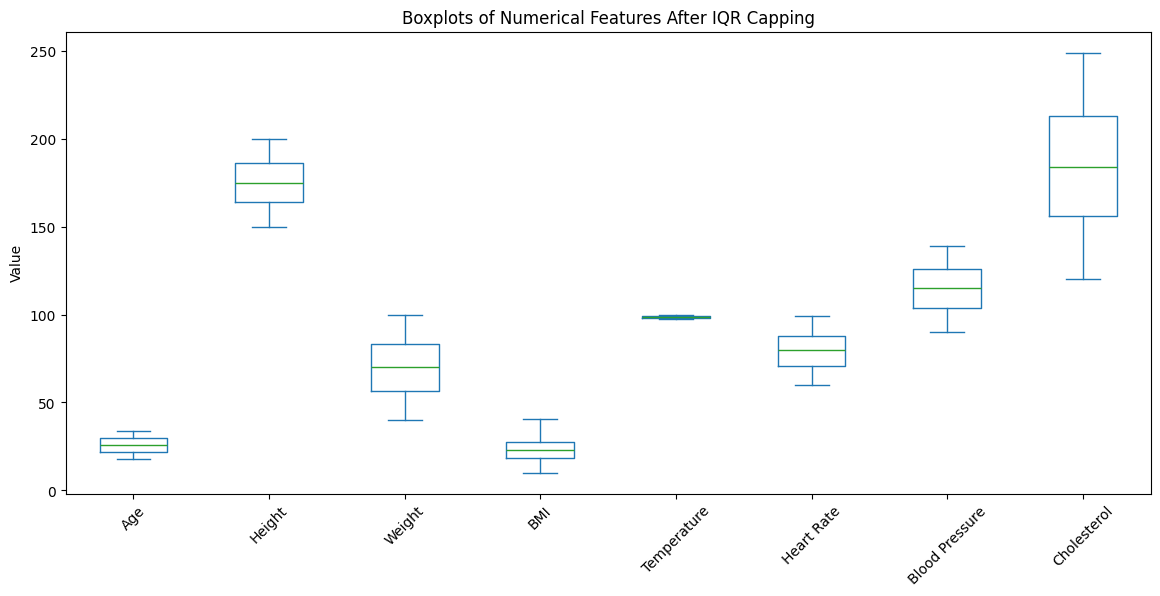

In [13]:
# Optional visualization: boxplots after IQR capping
df_iqr[numeric_features].plot(kind="box", figsize=(14, 6), rot=45)
plt.title("Boxplots of Numerical Features After IQR Capping")
plt.ylabel("Value")
plt.show()

## Task 4: Normalize Numerical Features Using Min-Max and Z-score

Two normalization methods are applied:

### Min-Max Scaling

Min-Max scaling transforms values to the range 0 to 1. It is useful when we need bounded values.

### Z-score Standardization

Z-score standardization transforms values so each feature has mean 0 and standard deviation 1. It is commonly used before PCA because PCA is affected by feature scale.


In [14]:
# Min-Max normalization
minmax_scaler = MinMaxScaler()
df_minmax = df_iqr.copy()

df_minmax[numeric_features] = minmax_scaler.fit_transform(df_iqr[numeric_features])

print("Min-Max normalized numerical features:")
df_minmax[numeric_features].head()

Min-Max normalized numerical features:


,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
0,0.0000,0.2356,0.5392,0.5780,0.4990,0.8974,0.3878,0.6434
1,0.5000,0.0414,0.1272,0.4144,0.5482,0.8462,0.2857,0.3333
2,0.8750,0.6508,0.2623,0.2189,0.3545,0.4103,0.8163,0.7442
3,0.7500,0.6423,0.3889,0.2968,0.6013,1.0000,0.4490,0.1628
4,0.3125,0.4984,0.1039,0.4144,0.4481,0.8974,0.5102,0.8605


In [15]:
# Check Min-Max ranges
minmax_check = pd.DataFrame({
    "Min": df_minmax[numeric_features].min(),
    "Max": df_minmax[numeric_features].max()
})

minmax_check

,Min,Max
Age,0.0000,1.0000
Height,0.0000,1.0000
Weight,0.0000,1.0000
BMI,0.0000,1.0000
Temperature,0.0000,1.0000
Heart Rate,0.0000,1.0000
Blood Pressure,0.0000,1.0000
Cholesterol,0.0000,1.0000


In [16]:
# Z-score standardization
zscore_scaler = StandardScaler()
df_zscore = df_iqr.copy()

df_zscore[numeric_features] = zscore_scaler.fit_transform(df_iqr[numeric_features])

print("Z-score standardized numerical features:")
df_zscore[numeric_features].head()

Z-score standardized numerical features:


,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
0,-1.7319,-0.9630,0.1446,0.6620,-0.0028,1.4126,-0.4113,0.5218
1,-0.0043,-1.6725,-1.3626,-0.0885,0.2452,1.2296,-0.7779,-0.6032
2,1.2914,0.5542,-0.8682,-0.9848,-0.7318,-0.3257,1.1283,0.8874
3,0.8595,0.5232,-0.4054,-0.6278,0.5131,1.7785,-0.1913,-1.2219
4,-0.6521,-0.0025,-1.4478,-0.0885,-0.2597,1.4126,0.0286,1.3092


In [17]:
# Check Z-score mean and standard deviation
zscore_check = pd.DataFrame({
    "Mean": df_zscore[numeric_features].mean().round(4),
    "Standard Deviation": df_zscore[numeric_features].std().round(4)
})

zscore_check

,Mean,Standard Deviation
Age,0.0000,1.0000
Height,0.0000,1.0000
Weight,0.0000,1.0000
BMI,-0.0000,1.0000
Temperature,0.0000,1.0000
Heart Rate,-0.0000,1.0000
Blood Pressure,0.0000,1.0000
Cholesterol,0.0000,1.0000


## Task 5: Apply PCA and Interpret Explained Variance

PCA is applied to the Z-score standardized numerical features. Z-score standardization is used because PCA is sensitive to scale, and the numerical columns have different units such as age, height, weight, temperature, and cholesterol.


In [18]:
# Apply PCA on Z-score standardized numerical features
X_pca = df_zscore[numeric_features]

pca = PCA()
principal_components = pca.fit_transform(X_pca)

explained_variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance_df

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.2358,0.2358
1,PC2,0.1264,0.3622
2,PC3,0.1258,0.4880
3,PC4,0.1250,0.6130
4,PC5,0.1247,0.7377
5,PC6,0.1241,0.8618
6,PC7,0.1240,0.9858
7,PC8,0.0142,1.0000


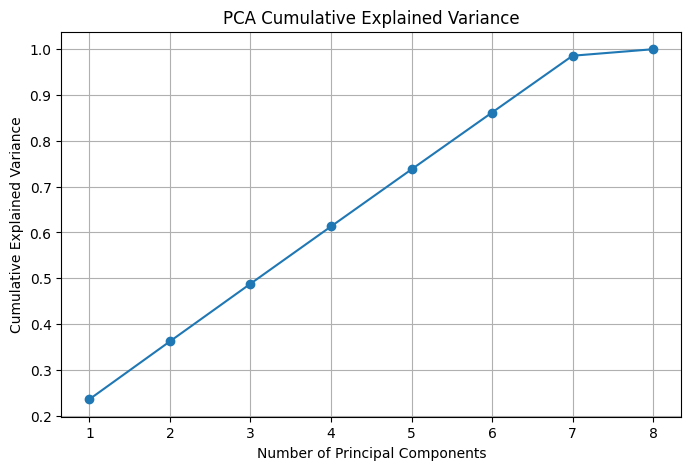

In [19]:
# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)
plt.show()

In [20]:
# Number of components needed to explain at least 90% and 95% of variance
components_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1
components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1

print("Components needed for at least 90% explained variance:", components_90)
print("Components needed for at least 95% explained variance:", components_95)

Components needed for at least 90% explained variance: 7
Components needed for at least 95% explained variance: 7


### PCA Interpretation

The explained variance ratio shows how much information each principal component captures from the standardized numerical features.

- PC1 captures the largest amount of variance.
- The cumulative explained variance shows how many components are needed to preserve most of the information.
- If fewer components explain a high percentage of variance, PCA can reduce dimensionality while keeping most of the dataset information.
- In this dataset, the number of components needed for 90% or 95% variance should be selected from the output above.


In [21]:
# Create a PCA dataframe for the selected number of components
selected_components = components_95

pca_selected = PCA(n_components=selected_components)
X_pca_selected = pca_selected.fit_transform(X_pca)

pca_columns = [f"PC{i+1}" for i in range(selected_components)]
df_pca = pd.DataFrame(X_pca_selected, columns=pca_columns)

print("PCA-transformed dataset shape:", df_pca.shape)
df_pca.head()

PCA-transformed dataset shape: (192356, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0.9189,0.0887,-0.9808,0.8987,-1.0616,0.6195,-1.6402
1,-0.2046,-0.9724,0.3974,0.6815,-1.4372,1.8535,-0.2933
2,-1.4235,1.0156,-0.1360,0.4044,0.3598,-0.0840,1.7387
3,-0.8827,0.6993,1.5044,-0.6485,-0.2969,1.4295,-0.6658
4,-0.9238,0.7750,-0.6706,1.4773,-0.9852,0.5551,-0.5693


## Final Summary

The dataset was cleaned and prepared through the following steps:

1. Data quality issues were identified, including missing values, duplicate rows, duplicate student IDs, mixed data types, and possible outliers.
2. Missing numerical values were filled with the median, and missing categorical values were filled with the mode.
3. Outliers were detected using IQR and handled by capping to the lower and upper IQR bounds.
4. Numerical features were normalized using both Min-Max scaling and Z-score standardization.
5. PCA was applied to the Z-score standardized numerical features, and explained variance was interpreted using the cumulative explained variance table and plot.
